In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings("ignore")

In [74]:
df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/classification-f08.csv')

df.tail(10)

,A,B,C,Z
490,45.943282,16.984269,40.936352,0
491,28.505393,27.621592,31.982748,1
492,22.100103,30.673230,32.153172,1
493,28.910155,31.936045,30.584097,1
494,41.979039,25.214705,35.931303,0
495,NaN,NaN,NaN,1
496,NaN,NaN,NaN,1
497,NaN,NaN,NaN,0
498,NaN,NaN,NaN,1
499,NaN,NaN,NaN,0


In [75]:
df.isnull().sum()

,0
A,5
B,5
C,5
Z,0


In [76]:
print(df.columns)

Index(['A', 'B', 'C', 'Z'], dtype='object')


In [77]:
print(df[(df['A'] == ' ') | (df['A'].isnull())])

      A   B   C  Z
495 NaN NaN NaN  1
496 NaN NaN NaN  1
497 NaN NaN NaN  0
498 NaN NaN NaN  1
499 NaN NaN NaN  0


In [78]:
print(df[(df['B'] == ' ') | (df['B'].isnull())])

      A   B   C  Z
495 NaN NaN NaN  1
496 NaN NaN NaN  1
497 NaN NaN NaN  0
498 NaN NaN NaN  1
499 NaN NaN NaN  0


In [79]:
print(df[(df['C'] == ' ') | (df['C'].isnull())])

      A   B   C  Z
495 NaN NaN NaN  1
496 NaN NaN NaN  1
497 NaN NaN NaN  0
498 NaN NaN NaN  1
499 NaN NaN NaN  0


In [80]:
df['A'].unique()

array([39.87909404, 18.36072654, 15.94965199, 26.5027514 , 17.02031652,
       41.32246419, 43.39900443, 38.62635017, 21.87507997, 20.43385376,
       24.28170063, 19.59420173, 34.066826  , 22.69819863, 25.35510363,
       28.84621652, 31.29453225, 33.64680601, 30.92265105, 30.39566127,
       19.41326729, 41.35785559, 44.80278981, 41.49030486, 45.06877894,
       20.90098452, 44.81665483, 25.51018133, 20.45633998, 29.39726164,
       31.30921117, 43.96413133, 29.50860396, 21.49452263, 39.58149031,
       31.87811175, 32.6522852 , 32.93838661, 37.80542267, 13.2416406 ,
       38.60594197, 19.20608874, 21.02138456, 26.50753167, 35.79025942,
       10.        , 22.65771674, 20.48423338, 41.94526538, 42.51233148,
       31.9813354 , 30.97924822, 41.3780973 , 24.6593084 , 36.80374614,
       37.73433177, 38.16664725, 30.88913228, 19.52277229, 38.91716368,
       41.38608318, 42.58583665, 35.1491827 , 45.26207603, 15.89002721,
       39.63175757, 24.53017444, 31.50696784, 18.37108726, 42.03

In [81]:
df[df['A'] == 'nan']

,A,B,C,Z


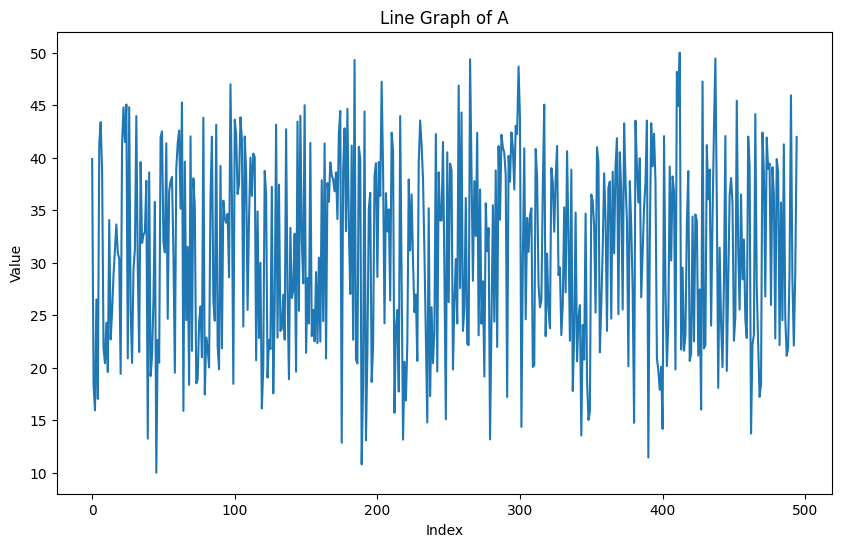

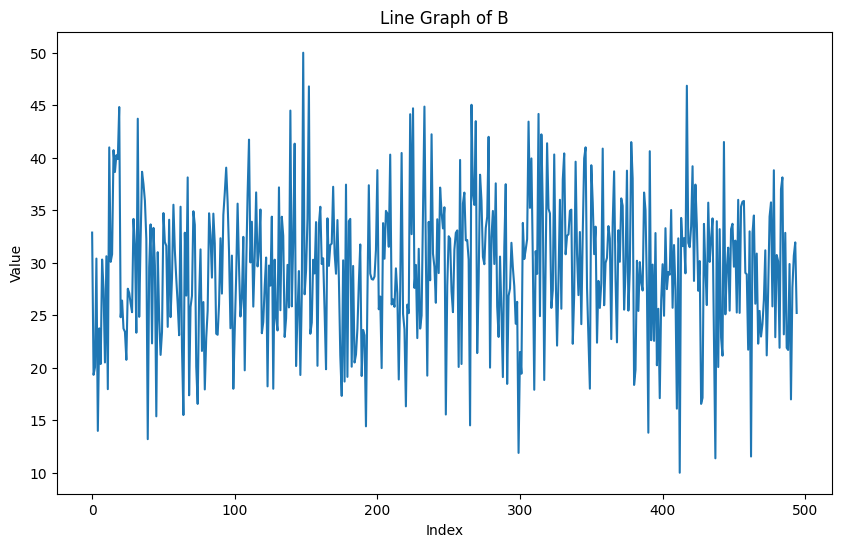

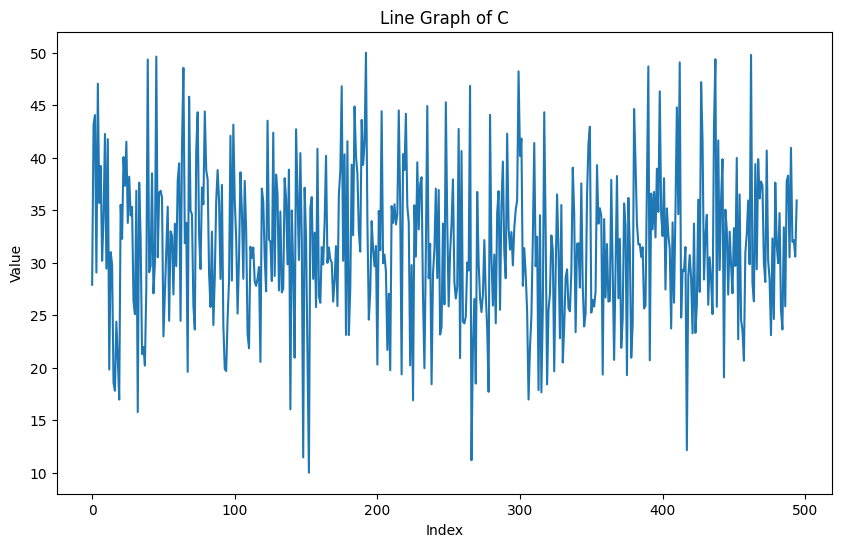

In [82]:

# Separate the data into columns
a = df['A']
b = df['B']
c = df['C']

# Plot A
plt.figure(figsize=(10, 6))
plt.plot(a)
plt.title('Line Graph of A')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

# Plot B
plt.figure(figsize=(10, 6))
plt.plot(b)
plt.title('Line Graph of B')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

# Plot C
plt.figure(figsize=(10, 6))
plt.plot(c)
plt.title('Line Graph of C')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

In [83]:
# prompt: Predict the values of column A, B, C at index 495 to 499, base in with means and other mathematical basis to predict the values

# Impute missing values with the mean of each column
df['A'].fillna(df['A'].mean(), inplace=True)
df['B'].fillna(df['B'].mean(), inplace=True)
df['C'].fillna(df['C'].mean(), inplace=True)

# Convert columns A, B, and C to numeric
df['A'] = pd.to_numeric(df['A'])
df['B'] = pd.to_numeric(df['B'])
df['C'] = pd.to_numeric(df['C'])

# Fit an ARIMA model to each column
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model to column A
model_a = ARIMA(df['A'], order=(5,1,0))
model_a_fit = model_a.fit()

# Fit ARIMA model to column B
model_b = ARIMA(df['B'], order=(5,1,0))
model_b_fit = model_b.fit()

# Fit ARIMA model to column C
model_c = ARIMA(df['C'], order=(5,1,0))
model_c_fit = model_c.fit()

# Predict future values for each column
forecast_a = model_a_fit.predict(start=495, end=499)
forecast_b = model_b_fit.predict(start=495, end=499)
forecast_c = model_c_fit.predict(start=495, end=499)

# Print the predicted values
print("Predicted values for column A (index 495-499):", forecast_a)
print("Predicted values for column B (index 495-499):", forecast_b)
print("Predicted values for column C (index 495-499):", forecast_c)


Predicted values for column A (index 495-499): 495    32.981438
496    31.984933
497    30.613792
498    31.136255
499    33.220620
Name: predicted_mean, dtype: float64
Predicted values for column B (index 495-499): 495    27.472195
496    26.565079
497    28.720682
498    29.519766
499    29.212359
Name: predicted_mean, dtype: float64
Predicted values for column C (index 495-499): 495    33.465021
496    34.136344
497    32.435232
498    31.995895
499    32.008251
Name: predicted_mean, dtype: float64


In [84]:
df.isnull().sum()

,0
A,0
B,0
C,0
Z,0


In [85]:
df.tail(10)

,A,B,C,Z
490,45.943282,16.984269,40.936352,0
491,28.505393,27.621592,31.982748,1
492,22.100103,30.673230,32.153172,1
493,28.910155,31.936045,30.584097,1
494,41.979039,25.214705,35.931303,0
495,31.054010,29.325002,31.623939,1
496,31.054010,29.325002,31.623939,1
497,31.054010,29.325002,31.623939,0
498,31.054010,29.325002,31.623939,1
499,31.054010,29.325002,31.623939,0


In [86]:
df.isnull().sum()

,0
A,0
B,0
C,0
Z,0


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       500 non-null    float64
 1   B       500 non-null    float64
 2   C       500 non-null    float64
 3   Z       500 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 15.8 KB


In [88]:
X = df.drop('Z', axis = 1)
scaler = StandardScaler()
scaler.fit(X)

StandardScaler()

In [89]:
scaled_features = scaler.transform(X)
scaled_features

array([[ 9.77736158e-01,  5.25624315e-01, -5.18983337e-01],
       [-1.40629612e+00, -1.48308439e+00,  1.60808341e+00],
       [-1.67342045e+00, -1.37602206e+00,  1.73575216e+00],
       ...,
       [-3.93607186e-16,  0.00000000e+00,  4.95643358e-16],
       [-3.93607186e-16,  0.00000000e+00,  4.95643358e-16],
       [-3.93607186e-16,  0.00000000e+00,  4.95643358e-16]])

In [90]:
scaled_features = pd.DataFrame(scaled_features, columns = df.columns[1:]) # all columns except the first one
scaled_features.tail(5)

,B,C,Z
495,-3.936072e-16,0.0,4.956434e-16
496,-3.936072e-16,0.0,4.956434e-16
497,-3.936072e-16,0.0,4.956434e-16
498,-3.936072e-16,0.0,4.956434e-16
499,-3.936072e-16,0.0,4.956434e-16


In [91]:
X = scaled_features.iloc[:499,:]
y = df.iloc[:499, 0]

In [92]:
X

,B,C,Z
0,9.777362e-01,0.525624,-5.189833e-01
1,-1.406296e+00,-1.483084,1.608083e+00
2,-1.673420e+00,-1.376022,1.735752e+00
3,-5.042365e-01,0.158568,-3.570299e-01
4,-1.554801e+00,-2.274339,2.151609e+00
...,...,...,...
494,1.210390e+00,-0.609409,6.009254e-01
495,-3.936072e-16,0.000000,4.956434e-16
496,-3.936072e-16,0.000000,4.956434e-16
497,-3.936072e-16,0.000000,4.956434e-16


In [93]:
y

,A
0,39.879094
1,18.360727
2,15.949652
3,26.502751
4,17.020317
...,...
494,41.979039
495,31.054010
496,31.054010
497,31.054010


In [94]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 101)

In [95]:
X_train

,B,C,Z
352,0.267031,0.220852,-0.809853
391,0.099989,1.674533,-1.523342
86,-0.728601,0.370475,-0.414316
237,-1.524323,-0.147981,0.024888
397,-1.253213,-0.550452,0.448775
...,...,...,...
63,1.574120,-1.103060,1.304697
326,1.114522,-1.070146,0.680974
337,-1.469975,-1.044820,1.036635
11,-1.269639,-1.685344,1.415866


In [96]:
y_train

,A
352,33.464240
391,31.956511
86,24.477633
237,17.295410
397,19.742459
...,...
63,45.262076
326,41.113731
337,17.785963
11,19.594202


In [100]:
bins = [df['Z'].min(), df['Z'].quantile(0.33), df['Z'].quantile(0.66), df['Z'].max()]
labels = ['low', 'medium', 'high']


In [99]:
df['Z_discrete'] = pd.cut(df['Z'], bins=bins, labels=labels, include_lowest=True)

ValueError: Bin edges must be unique: Index([0.0, 0.0, 1.0, 1.0], dtype='float64').
You can drop duplicate edges by setting the 'duplicates' kwarg

In [ ]:
X = df.drop(['Z', 'Z_discrete'], axis=1) # Drop both original 'Z' and the new discrete 'Z'
scaler = StandardScaler()
scaler.fit(X)
scaled_features = scaler.transform(X)


In [ ]:
scaled_features = pd.DataFrame(scaled_features, columns = [col for col in df.columns if col not in ['Z', 'Z_discrete']])

In [ ]:
X = scaled_features.iloc[:499,:]

In [ ]:
y = df['Z_discrete'].iloc[:499]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 101)

In [ ]:
# Create a Support Vector Machine Classifier

r_state = 101

model = SVC(random_state = r_state)
model.fit(X_train, y_train)